In [2]:
#Import packages

import pandas as pd
import numpy as np
import chardet
import re
import emoji

## Step 1.1: Load Datasets

In [4]:
# Load Excel
file_path = "dataset/Indo-HateSpeech_Dataset.xlsx"
xls = pd.ExcelFile(file_path)
df = xls.parse("PostID Edited Comments Hindi")

# Keep only comment and label
hatespeech_df = df[["Comment", "Label"]].copy()

# Clean and map labels
hatespeech_df["Label"] = hatespeech_df["Label"].astype(str).str.strip("'").map({"HS0": 0, "HS1": 1})
hatespeech_df = hatespeech_df.dropna(subset=["Label"])
hatespeech_df["Label"] = hatespeech_df["Label"].astype(int)

# Rename columns
hatespeech_df = hatespeech_df.rename(columns={
    "Comment": "Code mixed text",
    "Label": "Hate or Non Hate speech"
})

# Drop rows with missing comments
hatespeech_df = hatespeech_df.dropna(subset=["Code mixed text"])

# Convert to string explicitly
hatespeech_df["Code mixed text"] = hatespeech_df["Code mixed text"].astype(str)

# Function to check if all words are in English
def is_english_only(text):
    return all(re.match("^[a-zA-Z]+$", word) for word in text.split())

# Apply filter
english_only_df = hatespeech_df[hatespeech_df["Code mixed text"].apply(is_english_only)]

# Reset index
english_only_df = english_only_df.reset_index(drop=True)

# Preview
print(english_only_df.dtypes)
print(english_only_df.head())


Code mixed text            object
Hate or Non Hate speech     int64
dtype: object
                                     Code mixed text  Hate or Non Hate speech
0  Nice buro yes I am Hussain khan is me happy ow...                        0
1                                            Send me                        0
2  Ye india ke sare muslman babar or akbar ki naj...                        0
3                                   Teri maa ki chut                        1
4                           owesi ki maa kaa cholaaa                        0


In [5]:
# # Read the dataset, check the independent and depentent features and visualize first few entries

# Column_names = ["Code mixed text", "Hate or Non Hate speech"]
# hatespeech_df = pd.read_csv("dataset/hate_speech.tsv", sep='\t', names=Column_names, header=None)

# hatespeech_df.columns
# hatespeech_df.head()

In [6]:
# Open the dataset
# Since the encoding is unknown, we use chardet to go through first 10k bytes and get a dictionary as result

with open("dataset/Hinglish_Profanity_List.csv", 'rb') as f:
    result = chardet.detect(f.read(10000))  # read first 10,000 bytes
    print(result)

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [7]:
# Use "encoding" attribute from result to read the dataset, 
# check the independent and depentent features and visualize first few entries

encoding_type = result['encoding']
profanity_df = pd.read_csv(
    "dataset/Hinglish_Profanity_List.csv",
    encoding=encoding_type,
    names=["Code mixed words", "English Meaning", "Severity scoring"],
    header=None
)

profanity_df.columns
profanity_df.head()

,Code mixed words,English Meaning,Severity scoring
0,badir,idiot,1
1,badirchand,idiot,1
2,bakland,idiot,1
3,bhadva,pimp,2
4,bhootnika,son of a witch,3


## Step 1.2: Explore the Structure

In [9]:
# Visualize the types of all features in both datasets.

hatespeech_df.info()
print()
profanity_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73868 entries, 0 to 77924
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Code mixed text          73868 non-null  object
 1   Hate or Non Hate speech  73868 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Code mixed words  209 non-null    object
 1   English Meaning   209 non-null    object
 2   Severity scoring  209 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.0+ KB


In [11]:
# Check for any existing missing values and drop those rows.

hatespeech_df[hatespeech_df.isnull().any(axis=1)].shape[0]
hatespeech_df.dropna(inplace=True)

## Step 2.1: Clean the Text

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace='')  # remove emojis
    text = re.sub(r'http\S+|www\S+', '', text)     # remove URLs
    # text = re.sub(r'@\w+|#\w+', '', text)          # remove @mentions and #hashtags
    text = re.sub(r'[^\w\s,\.]', '', text)         # keep commas and periods
    return text

# Apply the function to every row in "Code mixed text" column
hatespeech_df["Cleaned Text"] = hatespeech_df["Code mixed text"].apply(clean_text)

# Preview cleaned text
print(hatespeech_df[["Code mixed text", "Cleaned Text"]][10:11])


             Code mixed text        Cleaned Text
19  हमको एक मस्त बकरी चाहिए😍  हमक एक मसत बकर चहए


In [14]:
# Check the misspelled label rows.

hatespeech_df["Hate or Non Hate speech"].value_counts()

Hate or Non Hate speech
0    62834
1    11034
Name: count, dtype: int64

## Step 2.2: Handle Invalid Labels

In [16]:
# # Drop the misspelled label rows.

# hatespeech_df = hatespeech_df[~hatespeech_df["Hate or Non Hate speech"].isin(['n', 'on'])]

In [17]:
# Drop indices.

hatespeech_df = hatespeech_df.reset_index(drop=True)

In [18]:
# Check the balance or imbalance between labels

hatespeech_df["Hate or Non Hate speech"].value_counts()

Hate or Non Hate speech
0    62834
1    11034
Name: count, dtype: int64

In [19]:
# # Change the labels 'yes' or 'no' to '1' or '0' in hate speech dataset.

# hatespeech_df["HateOrNot"] = hatespeech_df["Hate or Non Hate speech"].map({
#     "yes": 1,
#     "no": 0
# })

## Step 3.1: Add Profanity-Based Features

In [21]:
# Strip whitespace and lowercase the profane words
profanity_df["Code mixed words"] = profanity_df["Code mixed words"].astype(str).str.strip().str.lower()

# Make a lookup dictionary for severity
profanity_dict = dict(zip(profanity_df["Code mixed words"], profanity_df["Severity scoring"]))

print(dict(list(profanity_dict.items())[:5]))

{'badir': 1, 'badirchand': 1, 'bakland': 1, 'bhadva': 2, 'bhootnika': 3}


In [22]:
from rapidfuzz import fuzz

# Enhanced normalizer
def normalize_word(word):
    substitutions = {
        '@': 'a', '0': 'o', '1': 'i', '$': 's', '!': 'i', '*': '', '#': '', '%': '', '&': 'and'
    }
    word = word.lower()
    for old, new in substitutions.items():
        word = word.replace(old, new)
    return word

# Pre-normalize the profanity dictionary
def build_normalized_profanity_dict(profanity_dict_raw):
    normalized_dict = {}
    for word, score in profanity_dict_raw.items():
        normalized_word = normalize_word(word)
        normalized_dict[normalized_word] = score
    return normalized_dict

# Extract profanity features with split detection
def extract_profanity_features(text, profanity_dict, max_len=100, fuzzy_threshold=85, min_len=3, max_ngram=4):
    words = text.split()
    count = 0
    severity_score = 0
    matched_phrases = set()

    norm_profanity_dict = build_normalized_profanity_dict(profanity_dict)

    for n in range(1, max_ngram + 1):  # 1-gram to 4-gram
        for i in range(len(words) - n + 1):
            ngram = " ".join(words[i:i + n])
            ngram_clean = normalize_word(ngram.replace(" ", ""))  # join and normalize

            if len(ngram_clean) < min_len or ngram_clean in matched_phrases:
                continue

            for profane_word in norm_profanity_dict:
                if fuzz.token_set_ratio(ngram_clean, profane_word) >= fuzzy_threshold:
                    count += 1
                    severity_score += norm_profanity_dict[profane_word]
                    matched_phrases.add(ngram_clean)
                    break

    binary_match = 1 if count > 0 else 0
    normalized_len = len(words) / max_len

    return count, severity_score, binary_match, normalized_len


In [23]:
# Extract all features and store in new columns
hatespeech_df[["profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]] = \
    hatespeech_df["Cleaned Text"].apply(lambda x: pd.Series(extract_profanity_features(x, profanity_dict)))

hatespeech_df.drop(columns=["Code mixed text"], inplace=True)
print(hatespeech_df[["Cleaned Text", "profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]].sample(5, random_state=42))

hatespeech_df.sample(5, random_state=42)

                                            Cleaned Text  profanity_count  \
35644  bc waqf bhi sarkar ke under aate h. padh to le...              0.0   
60584   aa loko ne let khabar mali k c banava ma kong...              1.0   
1165   iskay insta account pay jakey itni gali do or ...              0.0   
60496                                         moye moye               0.0   
28216                                                                 0.0   

       profanity_score  binary_profanity_match  normalized_text_len  
35644              0.0                     0.0                 0.13  
60584              8.0                     1.0                 0.27  
1165               0.0                     0.0                 0.21  
60496              0.0                     0.0                 0.02  
28216              0.0                     0.0                 0.00  


,Hate or Non Hate speech,Cleaned Text,profanity_count,profanity_score,binary_profanity_match,normalized_text_len
35644,1,bc waqf bhi sarkar ke under aate h. padh to le...,0.0,0.0,0.0,0.13
60584,1,aa loko ne let khabar mali k c banava ma kong...,1.0,8.0,1.0,0.27
1165,0,iskay insta account pay jakey itni gali do or ...,0.0,0.0,0.0,0.21
60496,0,moye moye,0.0,0.0,0.0,0.02
28216,0,,0.0,0.0,0.0,0.00


##  Step 3.2: Exploratory Data Analysis

['Hate or Non Hate speech', 'Cleaned Text', 'profanity_count', 'profanity_score', 'binary_profanity_match', 'normalized_text_len']


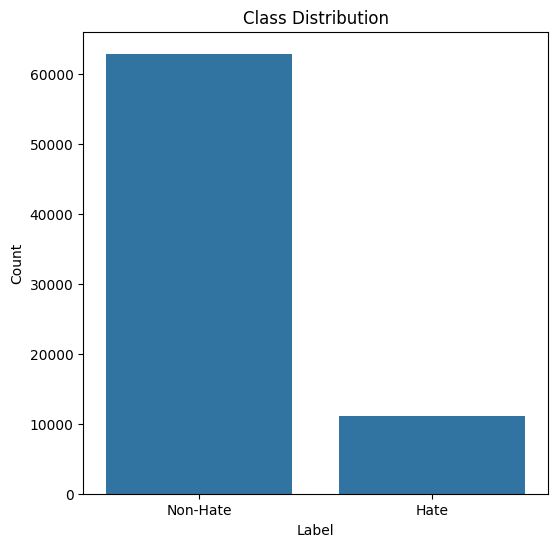

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Double check column name
print(hatespeech_df.columns.tolist())

plt.figure(figsize=(6, 6))
sns.countplot(x='Hate or Non Hate speech', data=hatespeech_df)
plt.xticks([0, 1], ['Non-Hate', 'Hate'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


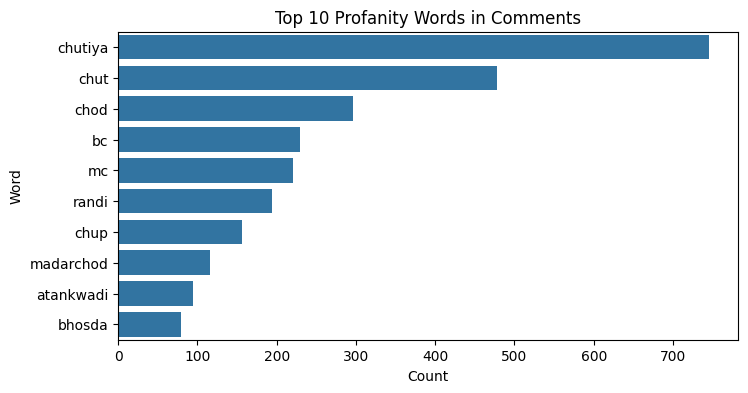

In [29]:
from collections import Counter

# Split all cleaned text into words
all_words = " ".join(hatespeech_df["Cleaned Text"]).split()

# Filter words that are in the profanity dictionary
profane_words = [word for word in all_words if word in profanity_dict]

# Count and plot top 10
top_profane = Counter(profane_words).most_common(10)

if top_profane:
    words, counts = zip(*top_profane)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts), y=list(words))
    plt.title("Top 10 Profanity Words in Comments")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()
else:
    print("No profane words found in the cleaned text.")


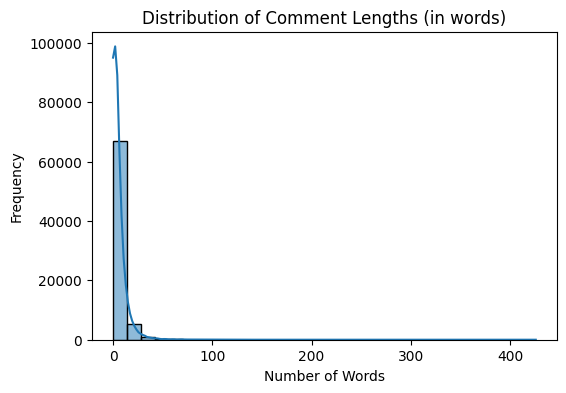

In [31]:
hatespeech_df['text_len'] = hatespeech_df['Cleaned Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6, 4))
sns.histplot(hatespeech_df['text_len'], bins=30, kde=True)
plt.title("Distribution of Comment Lengths (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


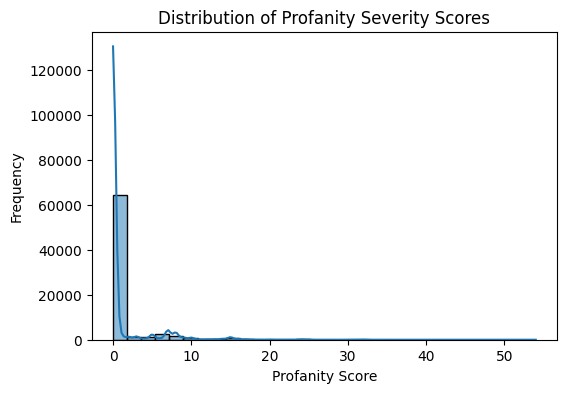

In [32]:
plt.figure(figsize=(6, 4))
sns.histplot(hatespeech_df['profanity_score'], bins=30, kde=True)
plt.title("Distribution of Profanity Severity Scores")
plt.xlabel("Profanity Score")
plt.ylabel("Frequency")
plt.show()


## Step 4.1: Hate vs Non-Hate Classification (Binary)

In [34]:
!pip install lightgbm

Batches:   0%|          | 0/2309 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[LightGBM] [Info] Number of positive: 47253, number of negative: 46998
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.498941 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 276135
[LightGBM] [Info] Number of data points in the train set: 94251, number of used features: 1272
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
              precision    recall  f1-score   support

    Non-Hate       0.93      0.94      0.94     15836
        Hate       0.94      0.93      0.94     15581

    accuracy                           0.94     31417
   macro avg       0.94      0.94      0.94     31417
weighted avg       0.94      0.94      0.94     31417



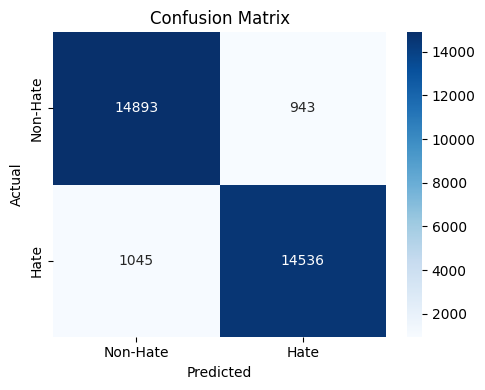

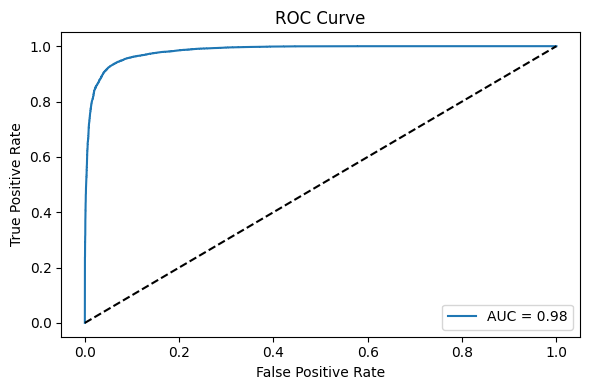

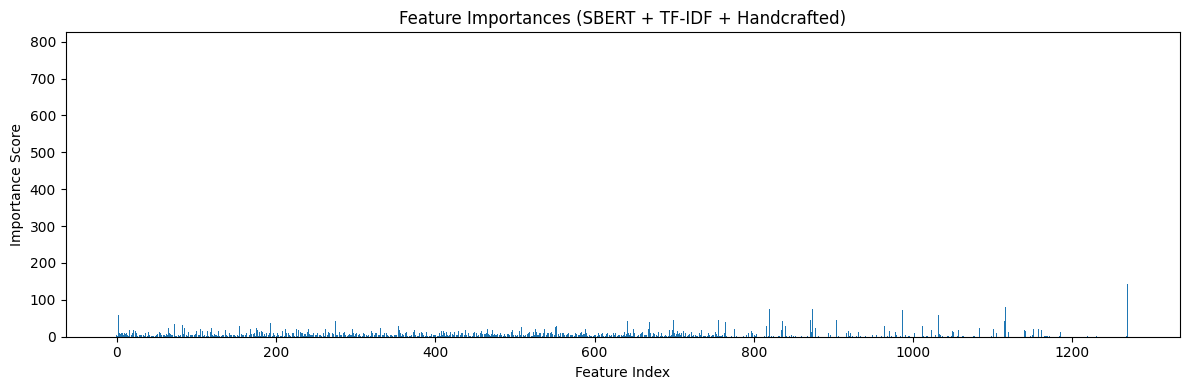

In [35]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your dataset (replace this with your actual data loading)
# Example: hatespeech_df = pd.read_csv("your_data.csv")

# Encode SBERT embeddings
sbert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
texts = hatespeech_df["Cleaned Text"].tolist()
text_embeddings = sbert_model.encode(texts, show_progress_bar=True)

# Generate TF-IDF features (1-2 grams, top 500 features)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
tfidf_features = tfidf.fit_transform(hatespeech_df["Cleaned Text"]).toarray()

# Prepare and scale handcrafted features
handcrafted = hatespeech_df[["profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]].values
scaler = StandardScaler()
handcrafted_scaled = scaler.fit_transform(handcrafted.astype(np.float32))

# Combine SBERT + TF-IDF + handcrafted features
X = np.hstack([
    np.array(text_embeddings).astype(np.float32),
    tfidf_features.astype(np.float32),
    handcrafted_scaled
])
y = hatespeech_df["Hate or Non Hate speech"].values

# Balance classes using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)

# Train LightGBM
clf = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=64,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred, target_names=["Non-Hate", "Hate"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Hate", "Hate"], yticklabels=["Non-Hate", "Hate"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importances (SBERT + TF-IDF + Handcrafted)")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


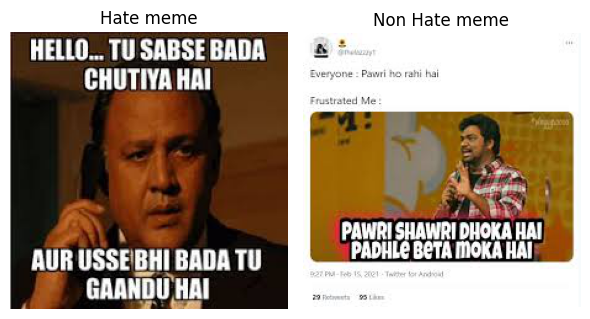

In [106]:
from PIL import Image
import matplotlib.pyplot as plt

# Load images
img1 = Image.open("dataset/Emoff_meme/Datasets/my_meme_data/babies184.png")
img2 = Image.open("dataset/Emoff_meme/Datasets/my_meme_data/babies0.png")

# Plot side by side
plt.figure(figsize=(6, 4))  # Adjust size as needed

# First image
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.axis('off')
plt.title("Hate meme")

# Second image
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis('off')
plt.title("Non Hate meme")

plt.tight_layout()
plt.show()

In [38]:
import pandas as pd

# Load both CSVs
df_emotions = pd.read_csv("dataset/Emoff_meme/Datasets/EMOFF_MEME.csv")
df_emotions.drop(columns='text', inplace=True)

df_emotions.head()

,Name,Level1,Level2,Level 3(Emotion1),Level 4(Emotion2),Level 5(Emotion3)
0,hindi_meme0.png,1,1,Envy,Neglect,Rage
1,hindi_meme11.png,1,1,Rage,Disappointment,Envy
2,hindi_meme13.png,0,0,Joy,none,none
3,hindi_meme14.png,0,0,Joy,Rage,Sadness
4,hindi_meme16.png,0,0,Joy,Pride,none


In [39]:
import pandas as pd

# Load both CSVs
df_memeText = pd.read_csv("extracted_memes_english_only.csv")


df_memeText.head()

,filename,comment,label
0,babies10.png,thlle,NaN
1,babies102.png,3a,NaN
2,babies0.png,NaN,NaN
3,babies100.png,nininibinis,NaN
4,babies101.png,NaN,NaN


In [40]:
# Merge 'comment' from df_memeText into df_emotions using 'Name' and 'filename'
merged_df = df_emotions.merge(
    df_memeText[['filename', 'comment']],
    how='left',
    left_on='Name',
    right_on='filename'
)

# Drop rows where 'comment' is NaN
filtered_df = merged_df[~merged_df['comment'].isna()].drop(columns=['filename', 'comment'])

# Now df_emotions is updated with only valid entries
df_emotions = filtered_df.reset_index(drop=True)

# Preview
print(df_emotions.head())

               Name  Level1  Level2 Level 3(Emotion1) Level 4(Emotion2)  \
0   hindi_meme0.png       1       1              Envy           Neglect   
1  hindi_meme11.png       1       1              Rage    Disappointment   
2  hindi_meme13.png       0       0               Joy              none   
3  hindi_meme14.png       0       0               Joy              Rage   
4  hindi_meme16.png       0       0               Joy             Pride   

  Level 5(Emotion3)  
0              Rage  
1              Envy  
2              none  
3           Sadness  
4              none  


In [41]:
# Step 1: Define hate-related emotions
HATE_EMOTIONS = {
    "Rage", "Disgust", "Anger", "Envy", "Fear",
    "Contempt", "Shame", "Neglect", "Disappointment"
}

# Step 2: Drop duplicates in df_emotions by 'Name' to ensure unique keys
df_unique_emotions = df_emotions.drop_duplicates(subset="Name", keep="first")

# Step 3: Create lookup dict
emotion_map = df_unique_emotions.set_index("Name")[[
    "Level1", "Level2",
    "Level 3(Emotion1)", "Level 4(Emotion2)", "Level 5(Emotion3)"
]].to_dict("index")

# Step 4: Label assignment function
def get_label(filename):
    row = emotion_map.get(filename)
    if not row:
        return None  # or 0 if you want to default missing entries to non-hate
    emotion = row["Level 3(Emotion1)"]
    if emotion in HATE_EMOTIONS:
        return 1
    return 0

# Step 5: Apply label assignment
df_memeText["label"] = df_memeText["filename"].apply(get_label)

# Step 6: Drop rows where label is NaN
df_memeText = df_memeText.dropna(subset=["label"])

# Step 7: Convert to integer
df_memeText["label"] = df_memeText["label"].astype(int)


In [42]:
df_memeText.head()

,filename,comment,label
0,babies10.png,thlle,0
1,babies102.png,3a,0
3,babies100.png,nininibinis,0
6,babies103.png,Phoolo ahT Taaron Ka Sabka chT Hai Ek R Kilo K...,0
8,babies107.png,Stinystep KITNI MOTI HOGYI HAI TU MOTI KISKO B...,0


In [43]:
df_memeText["label"].value_counts()

label
0    5087
1     894
Name: count, dtype: int64

In [44]:
print(df_memeText[df_memeText["label"] == 1].head(5))

          filename                                            comment  label
42   babies138.png                                                135      1
51   babies144.png                       t TRee www.trolitree.com Ill      1
90   babies184.png  HELLO..TUSABSEBADA CHUTIYA HAI AUR USSEBHI BAD...      1
139  babies226.png                                                 ay      1
154   babies24.png  Diwali  Rang fa Light's chKuch Logo Ki Yaad Aa...      1


In [45]:
def clean_text(text):
    text = str(text).lower()
    text = emoji.replace_emoji(text, replace='')  # remove emojis
    text = re.sub(r'http\S+|www\S+', '', text)     # remove URLs
    # text = re.sub(r'@\w+|#\w+', '', text)          # remove @mentions and #hashtags
    text = re.sub(r'[^\w\s,\.]', '', text)         # keep commas and periods
    return text

# Apply the function to every row in "Code mixed text" column
df_memeText["clean_comment"] = df_memeText["comment"].apply(clean_text)


In [46]:
# Extract all features and store in new columns
df_memeText[["profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]] = \
    df_memeText["clean_comment"].apply(lambda x: pd.Series(extract_profanity_features(x, profanity_dict)))

df_memeText.drop(columns=["comment"], inplace=True)
print(df_memeText[["clean_comment", "profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]].sample(5, random_state=42))

df_memeText.sample(5, random_state=42)

                                          clean_comment  profanity_count  \
6562  rereae iye ihb w9h hle hst okes 1012 20 jokes1...              0.0   
6334  whatsspptext.com prize winning joke of the yea...              0.0   
4864                   jww.bittusharmajokes.com f.   lh              0.0   
7956                       hindian hindian_ f  hindian_              0.0   
278                                                   .              0.0   

      profanity_score  binary_profanity_match  normalized_text_len  
6562              0.0                     0.0                 0.10  
6334              0.0                     0.0                 0.31  
4864              0.0                     0.0                 0.03  
7956              0.0                     0.0                 0.04  
278               0.0                     0.0                 0.01  


,filename,label,clean_comment,profanity_count,profanity_score,binary_profanity_match,normalized_text_len
6562,non_off2.png,0,rereae iye ihb w9h hle hst okes 1012 20 jokes1...,0.0,0.0,0.0,0.10
6334,modei_shah123.png,0,whatsspptext.com prize winning joke of the yea...,0.0,0.0,0.0,0.31
4864,m_117.png,0,jww.bittusharmajokes.com f. lh,0.0,0.0,0.0,0.03
7956,rel387.png,0,hindian hindian_ f hindian_,0.0,0.0,0.0,0.04
278,babies352.png,0,.,0.0,0.0,0.0,0.01


['filename', 'label', 'clean_comment', 'profanity_count', 'profanity_score', 'binary_profanity_match', 'normalized_text_len']


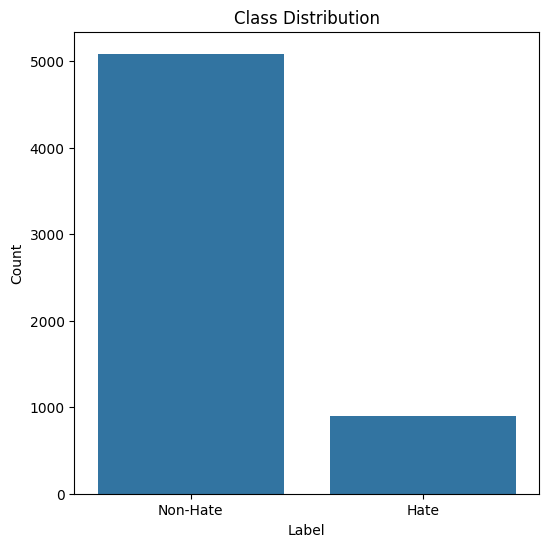

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Double check column name
print(df_memeText.columns.tolist())

plt.figure(figsize=(6, 6))
sns.countplot(x='label', data=df_memeText)
plt.xticks([0, 1], ['Non-Hate', 'Hate'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

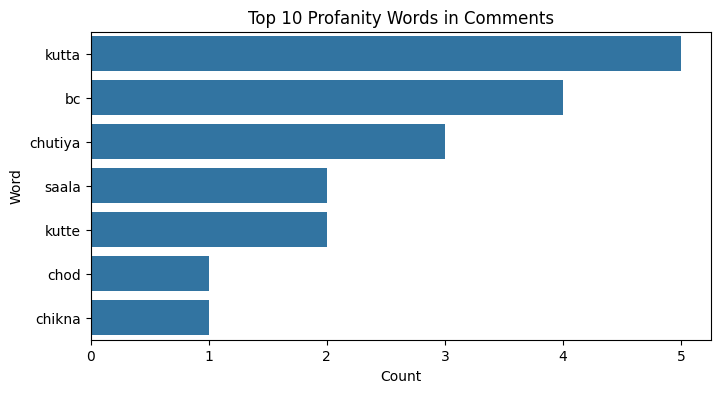

In [50]:
from collections import Counter

# Split all cleaned text into words
all_words = " ".join(df_memeText["clean_comment"]).split()

# Filter words that are in the profanity dictionary
profane_words = [word for word in all_words if word in profanity_dict]

# Count and plot top 10
top_profane = Counter(profane_words).most_common(10)

if top_profane:
    words, counts = zip(*top_profane)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts), y=list(words))
    plt.title("Top 10 Profanity Words in Comments")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()
else:
    print("No profane words found in the cleaned text.")


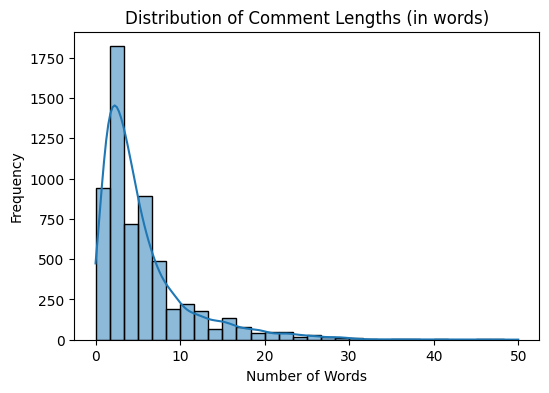

In [51]:
df_memeText['text_len'] = df_memeText['clean_comment'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6, 4))
sns.histplot(df_memeText['text_len'], bins=30, kde=True)
plt.title("Distribution of Comment Lengths (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


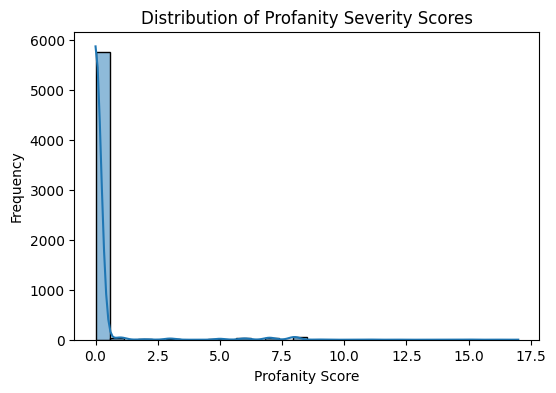

In [52]:
plt.figure(figsize=(6, 4))
sns.histplot(df_memeText['profanity_score'], bins=30, kde=True)
plt.title("Distribution of Profanity Severity Scores")
plt.xlabel("Profanity Score")
plt.ylabel("Frequency")
plt.show()


Batches:   0%|          | 0/187 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 3830, number of negative: 3800
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031242 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 200137
[LightGBM] [Info] Number of data points in the train set: 7630, number of used features: 1033
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

    Non-Hate       0.89      0.92      0.91      1287
        Hate       0.91      0.89      0.90      1257

    accuracy                           0.90      2544
   macro avg       0.90      0.90      0.90      2544
weighted avg       0.90      0.90      0.90      2544



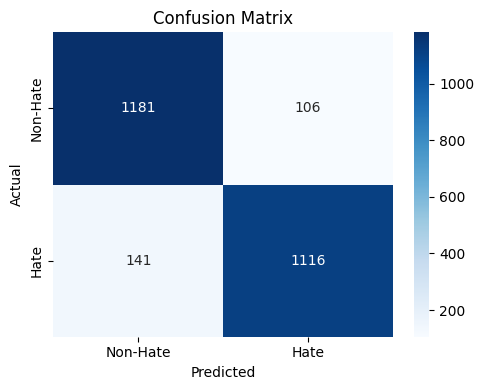

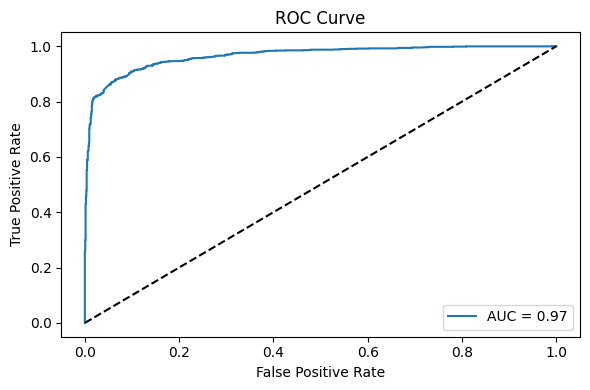

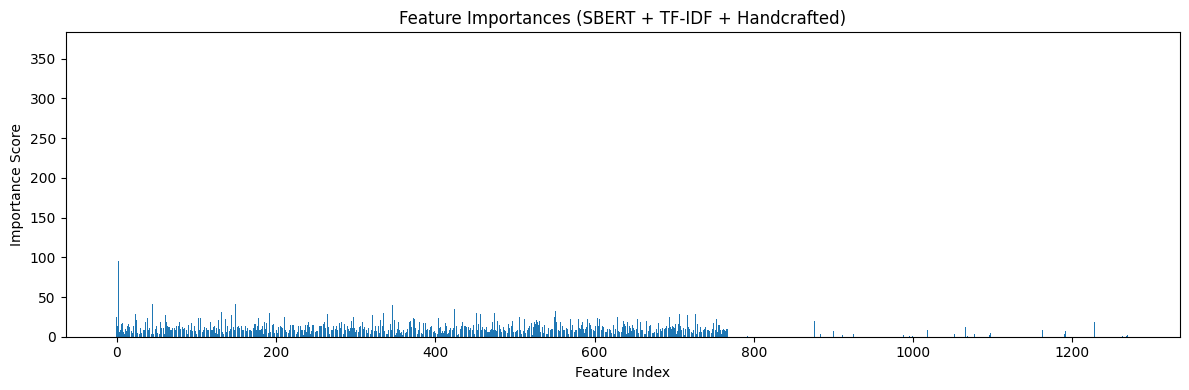

In [53]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your dataset (replace this with your actual data loading)
# Example: hatespeech_df = pd.read_csv("your_data.csv")

# Encode SBERT embeddings
sbert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
texts = df_memeText["clean_comment"].tolist()
text_embeddings = sbert_model.encode(texts, show_progress_bar=True)

# Generate TF-IDF features (1-2 grams, top 500 features)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
tfidf_features = tfidf.fit_transform(df_memeText["clean_comment"]).toarray()

# Prepare and scale handcrafted features
handcrafted = df_memeText[["profanity_count", "profanity_score", "binary_profanity_match", "normalized_text_len"]].values
scaler = StandardScaler()
handcrafted_scaled = scaler.fit_transform(handcrafted.astype(np.float32))

# Combine SBERT + TF-IDF + handcrafted features
X = np.hstack([
    np.array(text_embeddings).astype(np.float32),
    tfidf_features.astype(np.float32),
    handcrafted_scaled
])
y = df_memeText["label"].values

# Balance classes using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42)

# Train LightGBM
clf = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=64,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred, target_names=["Non-Hate", "Hate"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Hate", "Hate"], yticklabels=["Non-Hate", "Hate"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importances (SBERT + TF-IDF + Handcrafted)")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
